### Objective:-

Understand how UPI (Unified Payments Interface) is growing in India, both:

- Over time (month-by-month trends: volume, value, growth)

- Across states (per capita usage: which states use UPI the most/least relative to population)

In [84]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark
import os
import sys
from pyspark.sql import SparkSession,functions as F
from pyspark.sql.types import FloatType,DateType,IntegerType
from pyspark.sql.window import Window

In [85]:
#Set up Hadoop home environment variable
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] = os.environ["PATH"] + ";" + r"C:\hadoop\bin"

In [86]:
#Create Spark session
spark = SparkSession.builder.config("spark.hadoop.home.dir", "C:\\hadoop").appName('UPICaseStudy').getOrCreate()

In [87]:
#Read the CSV file into a Spark DataFrame
#Read the daily UPI data
upi_daily_df = spark.read.csv('datasets/upi_daily_trends.csv', header=True, inferSchema=True)

#Read the monthly UPI statewise data
state_UPI_df = spark.read.csv('datasets/upi_state.csv', header=True, inferSchema=True)

#Read state population data
state_population_df = spark.read.csv('datasets/indian_state_population.csv', header=True, inferSchema=True)

In [88]:
print("UPI Daily Trends DataFrame Schema:")
upi_daily_df.printSchema()

UPI Daily Trends DataFrame Schema:
root
 |-- Day: string (nullable = true)
 |-- Volume_in_Mn: double (nullable = true)
 |-- Value_in_Cr: string (nullable = true)



In [89]:
print("State UPI DataFrame Schema:")
state_UPI_df.printSchema()

State UPI DataFrame Schema:
root
 |-- SrNo: string (nullable = true)
 |-- StateUnionTerritory: string (nullable = true)
 |-- Volume: string (nullable = true)
 |-- VolumeContribution: string (nullable = true)
 |-- Value: string (nullable = true)
 |-- ValueContribution: string (nullable = true)



In [90]:
print("State Population DataFrame Schema:")
state_population_df.printSchema()

State Population DataFrame Schema:
root
 |-- SNo: integer (nullable = true)
 |-- State_Unionterritory: string (nullable = true)
 |-- Total_population: string (nullable = true)



Data Cleaning and Pre-processing 

1. UPI daily dataset

In [91]:
upi_daily_df.show(2)

+------------+------------+-----------+
|         Day|Volume_in_Mn|Value_in_Cr|
+------------+------------+-----------+
|July 1, 2025|      653.51|1,10,062.30|
|July 2, 2025|       665.0|1,04,976.26|
+------------+------------+-----------+
only showing top 2 rows


In [92]:
upi_daily_df = upi_daily_df.withColumn("Value_in_Cr", F.regexp_replace(F.col("Value_in_Cr"), ",", "").cast(FloatType())) 
upi_daily_df.show(3)

+------------+------------+-----------+
|         Day|Volume_in_Mn|Value_in_Cr|
+------------+------------+-----------+
|July 1, 2025|      653.51|   110062.3|
|July 2, 2025|       665.0|  104976.26|
|July 3, 2025|       644.7|   95041.19|
+------------+------------+-----------+
only showing top 3 rows


In [93]:
#Format the date column
upi_daily_df = upi_daily_df.withColumn("Date",F.to_date(F.col("Day"), "MMMM d, yyyy").cast(DateType()))
upi_daily_df = upi_daily_df.withColumn("YearMonth", F.date_format("Date", "yyyy-MM"))
upi_daily_df = upi_daily_df.withColumn("Year", F.year("Date"))
upi_daily_df = upi_daily_df.withColumn("Month", F.month("Date"))
upi_daily_df = upi_daily_df.drop("Day")
upi_daily_df.show(3)

+------------+-----------+----------+---------+----+-----+
|Volume_in_Mn|Value_in_Cr|      Date|YearMonth|Year|Month|
+------------+-----------+----------+---------+----+-----+
|      653.51|   110062.3|2025-07-01|  2025-07|2025|    7|
|       665.0|  104976.26|2025-07-02|  2025-07|2025|    7|
|       644.7|   95041.19|2025-07-03|  2025-07|2025|    7|
+------------+-----------+----------+---------+----+-----+
only showing top 3 rows


2. State-wise UPI Data

In [94]:
state_UPI_df.show(3)

+--------+-------------------+--------+------------------+-----------+-----------------+
|    SrNo|StateUnionTerritory|  Volume|VolumeContribution|      Value|ValueContribution|
+--------+-------------------+--------+------------------+-----------+-----------------+
|Jun 2025|        MAHARASHTRA|1,741.88|             9.47%|2,11,433.62|            8.80%|
|Jun 2025|          KARNATAKA|1,000.66|             5.44%|1,34,850.46|            5.61%|
|Jun 2025|      UTTAR PRADESH|  972.29|             5.29%|1,23,844.58|            5.15%|
+--------+-------------------+--------+------------------+-----------+-----------------+
only showing top 3 rows


In [95]:
state_UPI_df = state_UPI_df.withColumn("Volume", F.regexp_replace(F.col("Volume"), ",", "").cast(FloatType())) 
state_UPI_df = state_UPI_df.withColumn("Value", F.regexp_replace(F.col("Value"), ",", "").cast(FloatType())) 
state_UPI_df = state_UPI_df.withColumn("Date",F.to_date(F.col("SrNo"), "MMM yyyy").cast(DateType())).drop("SrNo")
state_UPI_df.show(3)

+-------------------+-------+------------------+---------+-----------------+----------+
|StateUnionTerritory| Volume|VolumeContribution|    Value|ValueContribution|      Date|
+-------------------+-------+------------------+---------+-----------------+----------+
|        MAHARASHTRA|1741.88|             9.47%|211433.62|            8.80%|2025-06-01|
|          KARNATAKA|1000.66|             5.44%|134850.45|            5.61%|2025-06-01|
|      UTTAR PRADESH| 972.29|             5.29%|123844.58|            5.15%|2025-06-01|
+-------------------+-------+------------------+---------+-----------------+----------+
only showing top 3 rows


In [96]:
state_UPI_df.select("StateUnionTerritory").distinct().sort("StateUnionTerritory").show(90)

+--------------------+
| StateUnionTerritory|
+--------------------+
|   ANDAMAN & NICOBAR|
|      ANDHRA PRADESH|
|   ARUNACHAL PRADESH|
|               ASSAM|
|               BIHAR|
|          CHANDIGARH|
|        CHHATTISGARH|
|DADRA & NAGAR HAV...|
|               DELHI|
|                 GOA|
|             GUJARAT|
|             HARYANA|
|    HIMACHAL PRADESH|
|   JAMMU AND KASHMIR|
|           JHARKHAND|
|           KARNATAKA|
|              KERALA|
|              LADAKH|
|         LAKSHADWEEP|
|      MADHYA PRADESH|
|         MAHARASHTRA|
|             MANIPUR|
|           MEGHALAYA|
|             MIZORAM|
|            NAGALAND|
|              ODISHA|
|          PUDUCHERRY|
|              PUNJAB|
|           RAJASTHAN|
|              SIKKIM|
|          TAMIL NADU|
|           TELANGANA|
|             TRIPURA|
|       UTTAR PRADESH|
|         UTTARAKHAND|
|       Unclassified#|
|         WEST BENGAL|
+--------------------+



In [97]:
state_UPI_df = state_UPI_df.withColumn(
    "StateUnionTerritory",
    F.when(F.col("StateUnionTerritory") == "Unclassified#", "OTHER")
    .otherwise(F.col("StateUnionTerritory")) # Important: if no condition matches, keep the original value
)

In [98]:
state_UPI_df.select("StateUnionTerritory").distinct().sort("StateUnionTerritory").show(90)

+--------------------+
| StateUnionTerritory|
+--------------------+
|   ANDAMAN & NICOBAR|
|      ANDHRA PRADESH|
|   ARUNACHAL PRADESH|
|               ASSAM|
|               BIHAR|
|          CHANDIGARH|
|        CHHATTISGARH|
|DADRA & NAGAR HAV...|
|               DELHI|
|                 GOA|
|             GUJARAT|
|             HARYANA|
|    HIMACHAL PRADESH|
|   JAMMU AND KASHMIR|
|           JHARKHAND|
|           KARNATAKA|
|              KERALA|
|              LADAKH|
|         LAKSHADWEEP|
|      MADHYA PRADESH|
|         MAHARASHTRA|
|             MANIPUR|
|           MEGHALAYA|
|             MIZORAM|
|            NAGALAND|
|              ODISHA|
|               OTHER|
|          PUDUCHERRY|
|              PUNJAB|
|           RAJASTHAN|
|              SIKKIM|
|          TAMIL NADU|
|           TELANGANA|
|             TRIPURA|
|       UTTAR PRADESH|
|         UTTARAKHAND|
|         WEST BENGAL|
+--------------------+



In [99]:
state_UPI_df=state_UPI_df.select(
    "StateUnionTerritory",
    "Volume",
    "Value",
    "Date")
state_UPI_df.show(3)

+-------------------+-------+---------+----------+
|StateUnionTerritory| Volume|    Value|      Date|
+-------------------+-------+---------+----------+
|        MAHARASHTRA|1741.88|211433.62|2025-06-01|
|          KARNATAKA|1000.66|134850.45|2025-06-01|
|      UTTAR PRADESH| 972.29|123844.58|2025-06-01|
+-------------------+-------+---------+----------+
only showing top 3 rows


3. population data

In [100]:
state_population_df.show(3)

+---+--------------------+----------------+
|SNo|State_Unionterritory|Total_population|
+---+--------------------+----------------+
|  1|       A & N Islands|         404,000|
|  2|      Andhra Pradesh|      53,340,000|
|  3|   Arunachal Pradesh|       1,576,000|
+---+--------------------+----------------+
only showing top 3 rows


In [101]:
state_population_df=state_population_df.withColumn("Total_population", F.regexp_replace(F.col("Total_population"), ",", "").cast(IntegerType()))
state_population_df=state_population_df.withColumn("State_Unionterritory", F.upper(F.col("State_Unionterritory")))
state_population_df = state_population_df.withColumn(
    "State_Unionterritory",
    F.when(F.col("State_Unionterritory") == "A & N ISLANDS", "ANDAMAN & NICOBAR")
    .when(F.col("State_Unionterritory") == "D & N HAVELI", "DADRA & NAGAR HAVELI")
    .otherwise(F.col("State_Unionterritory")) # Important: if no condition matches, keep the original value
)
state_population_df = state_population_df.drop("SNo")
state_population_df.show(3)


+--------------------+----------------+
|State_Unionterritory|Total_population|
+--------------------+----------------+
|   ANDAMAN & NICOBAR|          404000|
|      ANDHRA PRADESH|        53340000|
|   ARUNACHAL PRADESH|         1576000|
+--------------------+----------------+
only showing top 3 rows


FEATURE ENGINEERING

1. upi_daily_df
2. state_UPI_df
3. state_population_df

In [102]:
# 1. Aggregate daily data to monthly totals
# This will be the primary DataFrame for overall UPI trends

upi_monthly_agg_df = upi_daily_df.groupBy("YearMonth","Year","Month").agg(
    F.sum("Volume_in_Mn").alias("Monthly_Volume_Mn"),
    F.sum("Value_in_Cr").alias("Monthly_Value_Cr")
).orderBy("YearMonth")

print("Monthly Aggregated UPI Data:")
upi_monthly_agg_df.show(5)
upi_monthly_agg_df.printSchema()

Monthly Aggregated UPI Data:
+---------+----+-----+-----------------+-----------------+
|YearMonth|Year|Month|Monthly_Volume_Mn| Monthly_Value_Cr|
+---------+----+-----+-----------------+-----------------+
|  2023-01|2023|    1|8036.890000000001| 1299058.78515625|
|  2023-02|2023|    2|7534.760000000001| 1235846.58203125|
|  2023-03|2023|    3|8685.310000000001|    1404950.59375|
|  2023-04|2023|    4|          8863.27|1415504.716796875|
|  2023-05|2023|    5|9415.199999999997| 1489145.44921875|
+---------+----+-----+-----------------+-----------------+
only showing top 5 rows
root
 |-- YearMonth: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Monthly_Volume_Mn: double (nullable = true)
 |-- Monthly_Value_Cr: double (nullable = true)



In [103]:
# Month-over-Month (MoM) Growth using Window Functions 

window_spec_month = Window.orderBy("YearMonth")

upi_monthly_agg_df = upi_monthly_agg_df.withColumn(
    "Prev_Month_Volume", F.lag("Monthly_Volume_Mn", 1).over(window_spec_month)  # Get previous month's volume
).withColumn(
    "Prev_Month_Value", F.lag("Monthly_Value_Cr", 1).over(window_spec_month)    # Get previous month's value
).withColumn(
    "MoM_Volume_Growth_Pct",
    (((F.col("Monthly_Volume_Mn") - F.col("Prev_Month_Volume")) / F.col("Prev_Month_Volume")) * 100)  # Calculate MoM growth percentage for volume
).withColumn(
    "MoM_Value_Growth_Pct",
    (((F.col("Monthly_Value_Cr") - F.col("Prev_Month_Value")) / F.col("Prev_Month_Value")) * 100) # Calculate MoM growth percentage for value
)

print("Monthly Aggregated UPI Data with MoM Growth:")
upi_monthly_agg_df.show(5)



Monthly Aggregated UPI Data with MoM Growth:
+---------+----+-----+-----------------+-----------------+-----------------+-----------------+---------------------+--------------------+
|YearMonth|Year|Month|Monthly_Volume_Mn| Monthly_Value_Cr|Prev_Month_Volume| Prev_Month_Value|MoM_Volume_Growth_Pct|MoM_Value_Growth_Pct|
+---------+----+-----+-----------------+-----------------+-----------------+-----------------+---------------------+--------------------+
|  2023-01|2023|    1|8036.890000000001| 1299058.78515625|             NULL|             NULL|                 NULL|                NULL|
|  2023-02|2023|    2|7534.760000000001| 1235846.58203125|8036.890000000001| 1299058.78515625|   -6.247814764168727|  -4.866000203169934|
|  2023-03|2023|    3|8685.310000000001|    1404950.59375|7534.760000000001| 1235846.58203125|   15.269895789646917|  13.683252774046512|
|  2023-04|2023|    4|          8863.27|1415504.716796875|8685.310000000001|    1404950.59375|    2.048976950736348|  0.7512095

In [104]:
# Year-over-Year (YoY) Growth

window_spec_year = Window.partitionBy("Month").orderBy("Year")  # Partition by month to compare the same month across years

upi_monthly_agg_df = upi_monthly_agg_df.withColumn(
    "Prev_Year_Volume", F.lag("Monthly_Volume_Mn", 1).over(window_spec_year)      # Get the same month from the previous year
).withColumn(
    "Prev_Year_Value", F.lag("Monthly_Value_Cr", 1).over(window_spec_year)     # Get the same month from the previous year
).withColumn(
    "YoY_Volume_Growth_Pct",
    ((F.col("Monthly_Volume_Mn") - F.col("Prev_Year_Volume")) / F.col("Prev_Year_Volume") * 100)  # Calculate YoY growth percentage for volume
).withColumn(
    "YoY_Value_Growth_Pct",
    ((F.col("Monthly_Value_Cr") - F.col("Prev_Year_Value")) / F.col("Prev_Year_Value") * 100)  # Calculate YoY growth percentage for value
)

upi_monthly_agg_df.select("YearMonth","Year","Month","Prev_Year_Volume","Prev_Year_Value","YoY_Volume_Growth_Pct","YoY_Value_Growth_Pct").show(10)

+---------+----+-----+------------------+----------------+---------------------+--------------------+
|YearMonth|Year|Month|  Prev_Year_Volume| Prev_Year_Value|YoY_Volume_Growth_Pct|YoY_Value_Growth_Pct|
+---------+----+-----+------------------+----------------+---------------------+--------------------+
|  2023-01|2023|    1|              NULL|            NULL|                 NULL|                NULL|
|  2024-01|2024|    1| 8036.890000000001|1299058.78515625|    51.83783777058035|   41.72445297075648|
|  2025-01|2025|    1|12203.039999999997|1841083.95703125|    39.27701621890944|   27.53558014024317|
|  2023-02|2023|    2|              NULL|            NULL|                 NULL|                NULL|
|  2024-02|2024|    2| 7534.760000000001|1235846.58203125|     60.6248905074614|  47.904228732375934|
|  2025-02|2025|    2|           12102.7|1827869.35546875|   33.079395506787726|   20.16623051058924|
|  2023-03|2023|    3|              NULL|            NULL|                 NULL|  

In [105]:
# Calculating Average Transaction Value (ATV)

# Converting millions to actual numbers, and crores to actual rupees for accurate ATV
# 1 Cr = 10,000,000 Rs
# 1 Mn = 1,000,000 units
upi_monthly_agg_df = upi_monthly_agg_df.withColumn(
    "ATV_Rs",
    (F.col("Monthly_Value_Cr") * 10000000) / (F.col("Monthly_Volume_Mn") * 1000000)
)

In [106]:
print("\nUPI Monthly Aggregated Data with Growth Metrics and ATV:")
upi_monthly_agg_df.show(5, truncate=False) # Show 5 rows, don't truncate long strings
upi_monthly_agg_df.printSchema()


UPI Monthly Aggregated Data with Growth Metrics and ATV:
+---------+----+-----+------------------+----------------+------------------+----------------+---------------------+--------------------+------------------+----------------+---------------------+--------------------+------------------+
|YearMonth|Year|Month|Monthly_Volume_Mn |Monthly_Value_Cr|Prev_Month_Volume |Prev_Month_Value|MoM_Volume_Growth_Pct|MoM_Value_Growth_Pct|Prev_Year_Volume  |Prev_Year_Value |YoY_Volume_Growth_Pct|YoY_Value_Growth_Pct|ATV_Rs            |
+---------+----+-----+------------------+----------------+------------------+----------------+---------------------+--------------------+------------------+----------------+---------------------+--------------------+------------------+
|2023-01  |2023|1    |8036.890000000001 |1299058.78515625|NULL              |NULL            |NULL                 |NULL                |NULL              |NULL            |NULL                 |NULL                |1616.3699953044645

In [107]:
# Save this enriched DataFrame
upi_monthly_agg_df.write.mode("overwrite").option("header", "true").parquet("cleaned_data/upi_monthly_trends.parquet")
print("Saved cleaned_data/upi_monthly_trends.parquet")

Saved cleaned_data/upi_monthly_trends.parquet


In [108]:
state_UPI_df.printSchema()
state_population_df.printSchema()

root
 |-- StateUnionTerritory: string (nullable = true)
 |-- Volume: float (nullable = true)
 |-- Value: float (nullable = true)
 |-- Date: date (nullable = true)

root
 |-- State_Unionterritory: string (nullable = true)
 |-- Total_population: integer (nullable = true)



In [109]:
# 2. Enriching State UPI Data with Population

state_upi_with_pop_df = state_UPI_df.join(
    state_population_df,
    on=state_UPI_df["StateUnionTerritory"] == state_population_df["State_Unionterritory"],
    how="inner" # Use inner join to only keep states present in both datasets
).select(
    state_UPI_df["*"], # Select all columns from the state UPI dataframe
    state_population_df["Total_population"] # Add the population column
)

print("\nState UPI Data joined with Population Data:")
state_upi_with_pop_df.show(5, truncate=False)


State UPI Data joined with Population Data:
+-------------------+-------+---------+----------+----------------+
|StateUnionTerritory|Volume |Value    |Date      |Total_population|
+-------------------+-------+---------+----------+----------------+
|MAHARASHTRA        |1741.88|211433.62|2025-06-01|127360000       |
|KARNATAKA          |1000.66|134850.45|2025-06-01|68115000        |
|UTTAR PRADESH      |972.29 |123844.58|2025-06-01|238078000       |
|TELANGANA          |738.37 |118822.08|2025-06-01|38272000        |
|TAMIL NADU         |699.34 |105130.55|2025-06-01|77089000        |
+-------------------+-------+---------+----------+----------------+
only showing top 5 rows


In [110]:
#Calculate Per Capita Metrics
# Volume_Float is in Mn (Millions), Value_Float is in Cr (Crores)
state_upi_with_pop_df = state_upi_with_pop_df.withColumn(
    "Volume_Per_Capita",
    (F.col("Volume") * 1000000) / F.col("Total_population") # Convert volume from Mn to actual units and divide by population
).withColumn(
    "Value_Per_Capita",
    (F.col("Value") * 10000000) / F.col("Total_population") # Convert value from Cr to actual rupees and divide by population
)

print("\nState UPI Data with Per Capita Metrics:")
state_upi_with_pop_df.show(5, truncate=False)


State UPI Data with Per Capita Metrics:
+-------------------+-------+---------+----------+----------------+------------------+------------------+
|StateUnionTerritory|Volume |Value    |Date      |Total_population|Volume_Per_Capita |Value_Per_Capita  |
+-------------------+-------+---------+----------+----------------+------------------+------------------+
|MAHARASHTRA        |1741.88|211433.62|2025-06-01|127360000       |13.676821646378867|16601.258244346733|
|KARNATAKA          |1000.66|134850.45|2025-06-01|68115000        |14.69074320112356 |19797.467976950746|
|UTTAR PRADESH      |972.29 |123844.58|2025-06-01|238078000       |4.083913583058258 |5201.848895110006 |
|TELANGANA          |738.37 |118822.08|2025-06-01|38272000        |19.292694270411463|31046.738640520485|
|TAMIL NADU         |699.34 |105130.55|2025-06-01|77089000        |9.071852363572868 |13637.554887856893|
+-------------------+-------+---------+----------+----------------+------------------+------------------+
only 

In [111]:
# Save this enriched DataFrame
state_upi_with_pop_df.write.mode("overwrite").option("header", "true").parquet("cleaned_data/upi_state_per_capita.parquet")
print("Saved cleaned_data/upi_state_per_capita.parquet")

Saved cleaned_data/upi_state_per_capita.parquet


In [112]:
spark.stop()

Visualization

In [132]:
# Load monthly trends data
monthly_trends_pd = pd.read_parquet("cleaned_data/upi_monthly_trends.parquet")

In [133]:
monthly_trends_pd['YearMonth'] = pd.to_datetime(monthly_trends_pd['YearMonth'])
monthly_trends_pd.head()

,YearMonth,Year,Month,Monthly_Volume_Mn,Monthly_Value_Cr,Prev_Month_Volume,Prev_Month_Value,MoM_Volume_Growth_Pct,MoM_Value_Growth_Pct,Prev_Year_Volume,Prev_Year_Value,YoY_Volume_Growth_Pct,YoY_Value_Growth_Pct,ATV_Rs
0,2023-01-01,2023,1,8036.89,1.299059e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1616.369995
1,2024-01-01,2024,1,12203.04,1.841084e+06,12020.25,1.822949e+06,1.520684,0.994790,8036.89,1.299059e+06,51.837838,41.724453,1508.709270
2,2025-01-01,2025,1,16996.03,2.348037e+06,16730.03,2.324700e+06,1.589955,1.003879,12203.04,1.841084e+06,39.277016,27.535580,1381.520923
3,2023-02-01,2023,2,7534.76,1.235847e+06,8036.89,1.299059e+06,-6.247815,-4.866000,NaN,NaN,NaN,NaN,1640.193692
4,2024-02-01,2024,2,12102.70,1.827869e+06,12203.04,1.841084e+06,-0.822254,-0.717762,7534.76,1.235847e+06,60.624891,47.904229,1510.298822


From the graph, we can observe a general upward trend in UPI transaction volumes, with some fluctuations, reaching a peak around May 2025

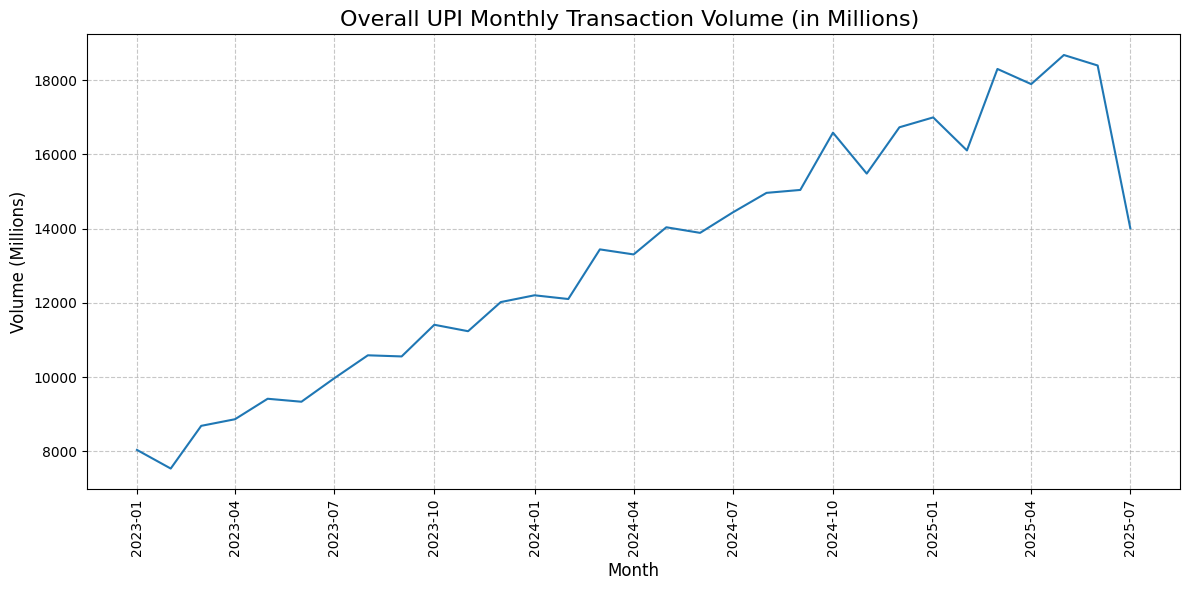

In [134]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trends_pd, x='YearMonth', y='Monthly_Volume_Mn')
plt.title('Overall UPI Monthly Transaction Volume (in Millions) ', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Volume (Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Similar to Volume, we can observe a general upward trend in UPI transaction Values, with some fluctuations, reaching a peak around May 2025

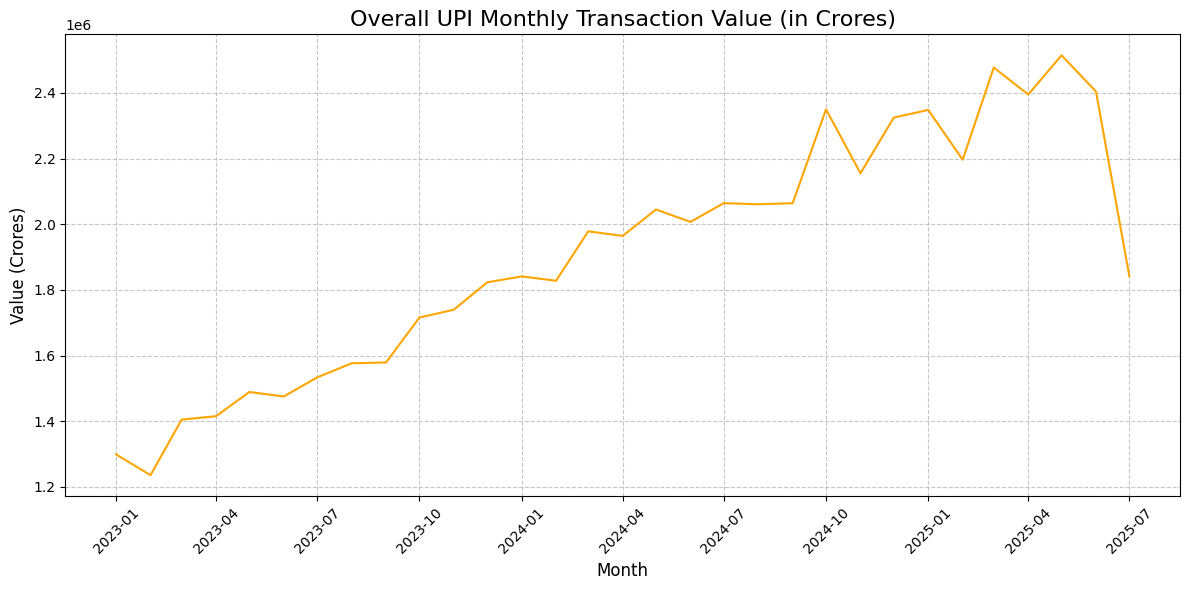

In [135]:
# Overall UPI Monthly Value Trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trends_pd, x='YearMonth', y='Monthly_Value_Cr', color='orange')
plt.title('Overall UPI Monthly Transaction Value (in Crores)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Value (Crores)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Transaction Value is calculated as "Total Value of Transactions / Number of Transactions (Volume)" 

- More People Using UPI: The number of transactions (volume) is rapidly increasing.
- For Smaller Payments: People are increasingly using UPI for very small everyday purchases.
- Average Value Going Down: Because of all these tiny transactions, the average amount per transaction is decreasing.
- Total Money Still Up: Even though each payment is smaller on average, so many payments are happening that the total amount of money transferred via UPI is still growing.

In short: UPI is being used by more people for smaller, more frequent payments.

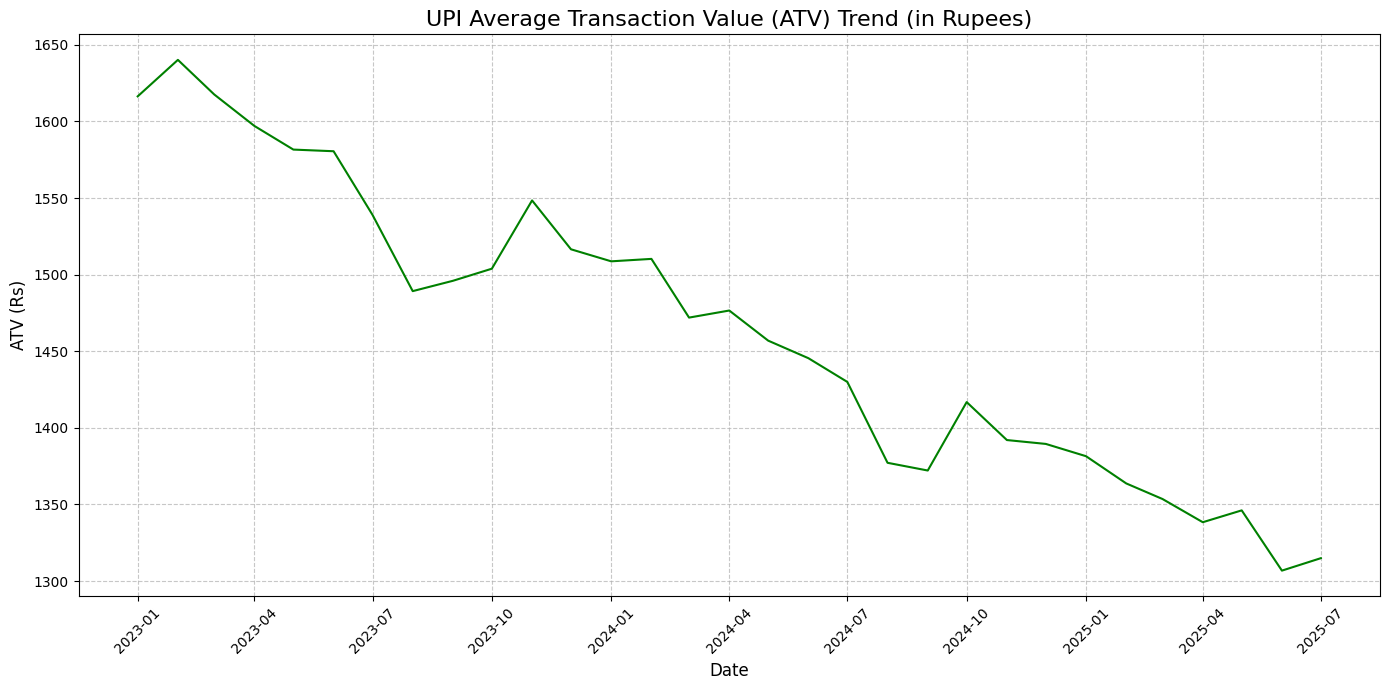

In [136]:
#UPI Average Transaction Value (ATV) Trend
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_trends_pd, x='YearMonth', y='ATV_Rs', color='green')
plt.title('UPI Average Transaction Value (ATV) Trend (in Rupees)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('ATV (Rs)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

While there are ups and downs, the growth has mostly been positive or slightly negative until the sharp decline towards the end of the depicted period

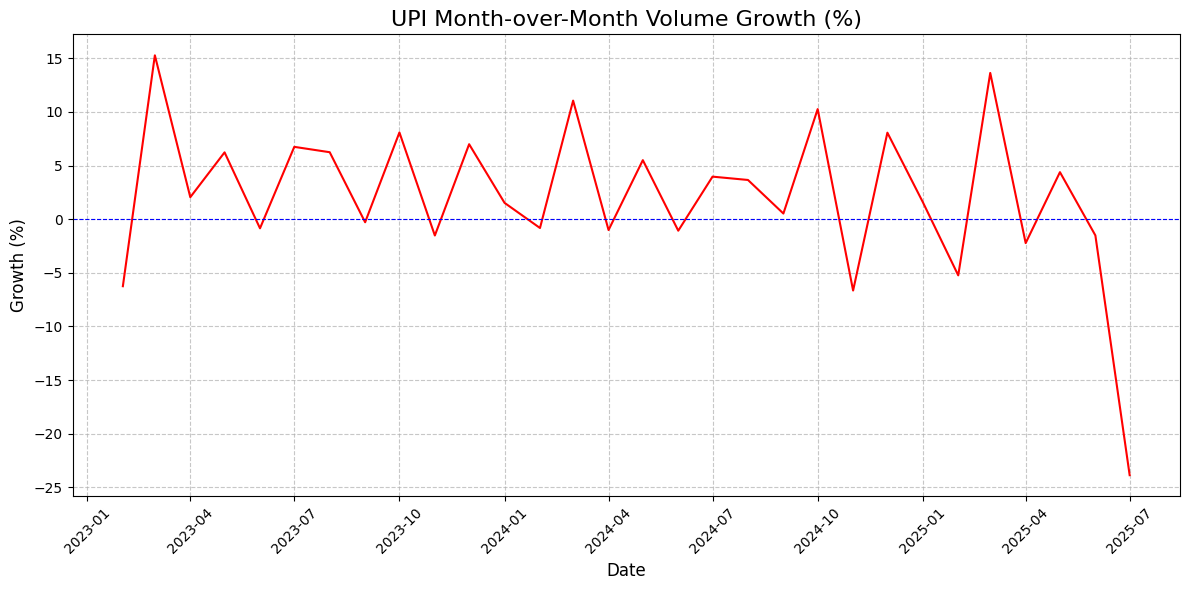

In [137]:
# MoM Volume Growth
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trends_pd, x='YearMonth', y='MoM_Volume_Growth_Pct', color='red')
plt.title('UPI Month-over-Month Volume Growth (%)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Growth (%)', fontsize=12)
plt.axhline(0, color='blue', linestyle='--', linewidth=0.8) # Add a line at 0 for reference
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Eventhough slight decline is noticed, overall trend has been positive growth

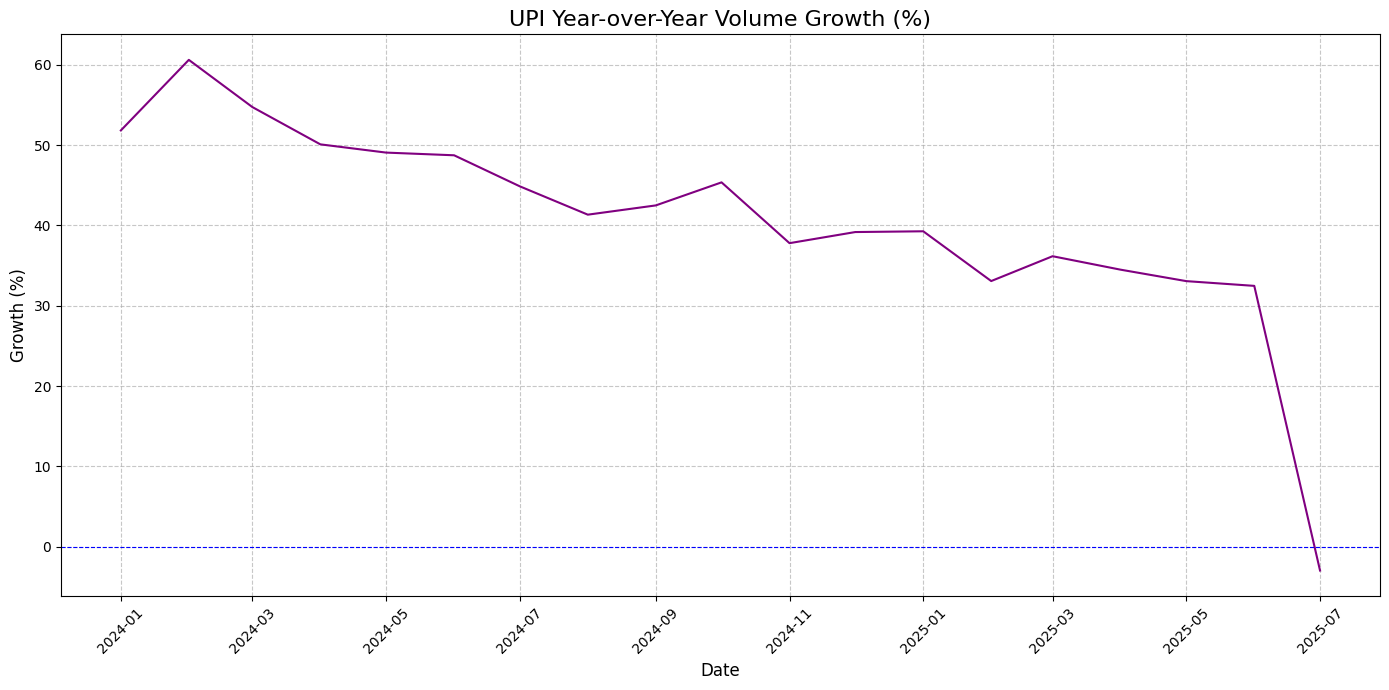

In [138]:
# YoY Volume Growth
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_trends_pd, x='YearMonth', y='YoY_Volume_Growth_Pct', color='purple')
plt.title('UPI Year-over-Year Volume Growth (%)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Growth (%)', fontsize=12)
plt.axhline(0, color='blue', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [140]:
state_per_capita_pd = pd.read_parquet("cleaned_data/upi_state_per_capita.parquet")

In [142]:
state_per_capita_pd['Date'] = pd.to_datetime(state_per_capita_pd['Date'])
state_per_capita_pd.head()

,StateUnionTerritory,Volume,Value,Date,Total_population,Volume_Per_Capita,Value_Per_Capita
0,MAHARASHTRA,1741.880005,211433.625000,2025-06-01,127360000,13.676822,16601.258244
1,KARNATAKA,1000.659973,134850.453125,2025-06-01,68115000,14.690743,19797.467977
2,UTTAR PRADESH,972.289978,123844.578125,2025-06-01,238078000,4.083914,5201.848895
3,TELANGANA,738.369995,118822.078125,2025-06-01,38272000,19.292694,31046.738641
4,TAMIL NADU,699.340027,105130.546875,2025-06-01,77089000,9.071852,13637.554888


In [143]:
# Find the latest date in the state per capita data
latest_date = state_per_capita_pd['Date'].max()
latest_month_state_data = state_per_capita_pd[state_per_capita_pd['Date'] == latest_date].copy()
print(f"\nAnalyzing state-wise data for the latest month: {latest_date.strftime('%Y-%m')}")


Analyzing state-wise data for the latest month: 2025-06


In [145]:
import warnings
warnings.filterwarnings("ignore")

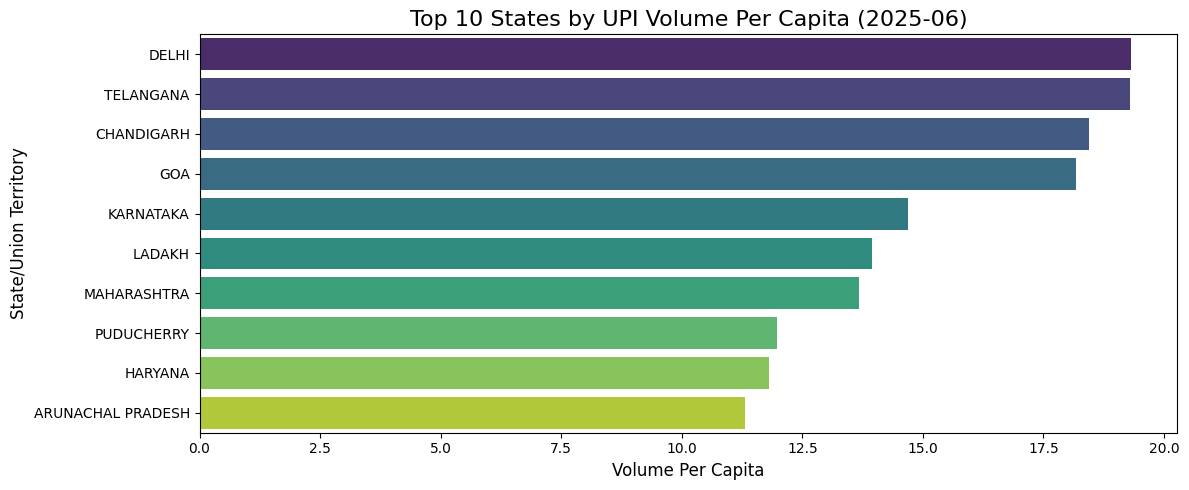

In [147]:
 # Top 10 States by Volume Per Capita
top_10_volume_per_capita = latest_month_state_data.nlargest(10, 'Volume_Per_Capita')
plt.figure(figsize=(12, 5))
sns.barplot(x='Volume_Per_Capita', y='StateUnionTerritory', data=top_10_volume_per_capita, palette='viridis')
plt.title(f'Top 10 States by UPI Volume Per Capita ({latest_date.strftime("%Y-%m")})', fontsize=16)
plt.xlabel('Volume Per Capita', fontsize=12)
plt.ylabel('State/Union Territory', fontsize=12)
plt.tight_layout()
plt.show()

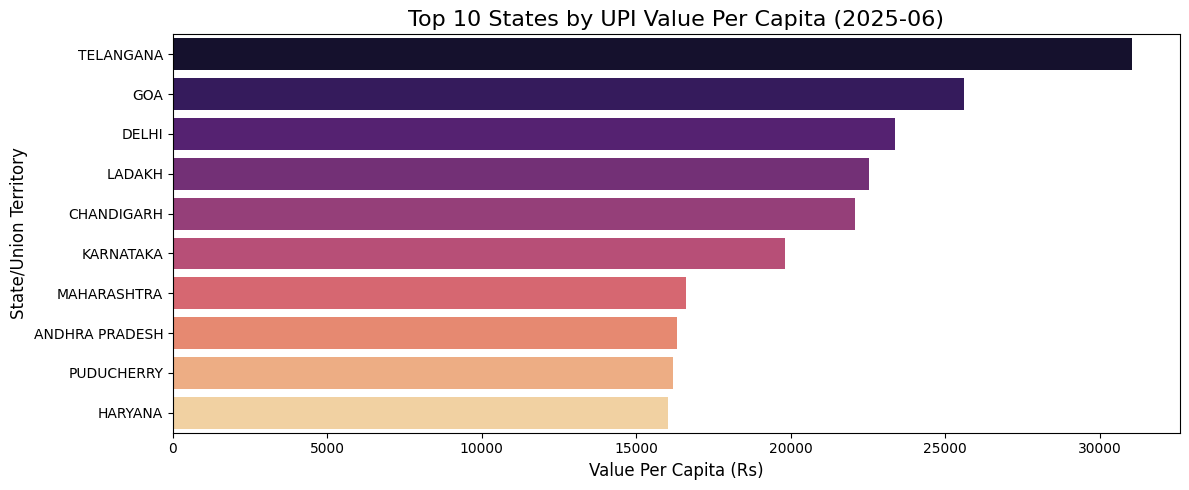

In [149]:
# Top 10 States by Value Per Capita
top_10_value_per_capita = latest_month_state_data.nlargest(10, 'Value_Per_Capita')
plt.figure(figsize=(12, 5))
sns.barplot(x='Value_Per_Capita', y='StateUnionTerritory', data=top_10_value_per_capita, palette='magma')
plt.title(f'Top 10 States by UPI Value Per Capita ({latest_date.strftime("%Y-%m")})', fontsize=16)
plt.xlabel('Value Per Capita (Rs)', fontsize=12)
plt.ylabel('State/Union Territory', fontsize=12)
plt.tight_layout()
plt.show()

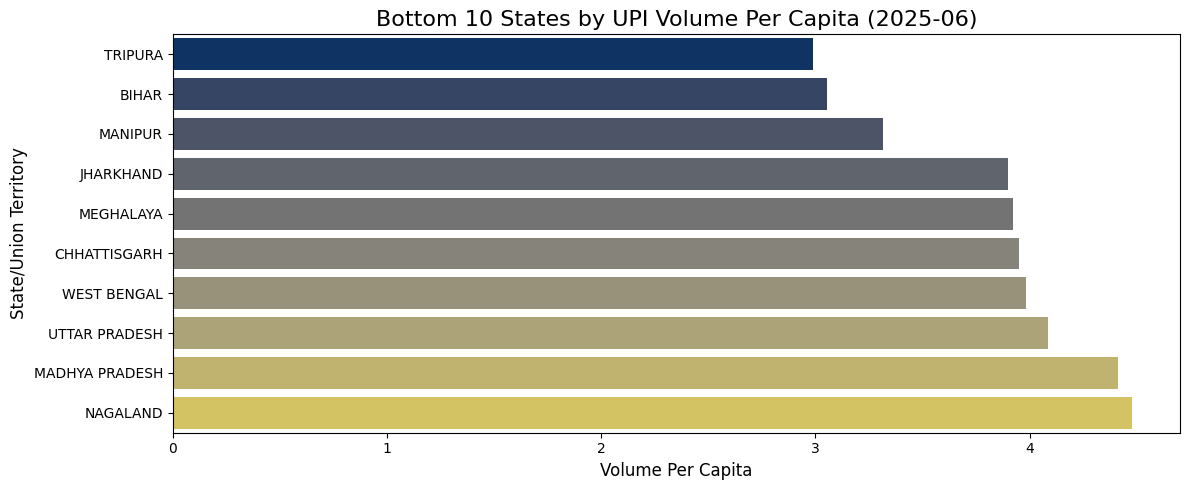

In [151]:
# Bottom 10 States by Volume Per Capita
bottom_10_volume_per_capita = latest_month_state_data.nsmallest(10, 'Volume_Per_Capita')
plt.figure(figsize=(12, 5))
sns.barplot(x='Volume_Per_Capita', y='StateUnionTerritory', data=bottom_10_volume_per_capita, palette='cividis')
plt.title(f'Bottom 10 States by UPI Volume Per Capita ({latest_date.strftime("%Y-%m")})', fontsize=16)
plt.xlabel('Volume Per Capita', fontsize=12)
plt.ylabel('State/Union Territory', fontsize=12)
plt.tight_layout()
plt.show()